In [120]:
from langgraph.store.memory import InMemoryStore
from dotenv import load_dotenv
from langchain_core.messages import SystemMessage
from pydantic import BaseModel, Field
from langgraph.graph import START, END, StateGraph, MessagesState
from typing import List
import uuid
from langchain_core.runnables import RunnableConfig
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.store.base import BaseStore
from langchain_groq import ChatGroq

In [121]:
load_dotenv()

store = InMemoryStore()

In [122]:
class MemoryDecision(BaseModel):
    should_write: bool = Field(description="whether to store the data in long term memory")
    memories : List[str] = Field(description="the details to be stored")

In [123]:
MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory.

CURRENT USER DETAILS (existing memories):
{user_details_content}

TASK:
- Review the user's latest message.
- Extract user-specific info worth storing long-term (identity, stable preferences, ongoing projects/goals).
- For each extracted item, set is_new=true ONLY if it adds NEW information compared to CURRENT USER DETAILS.
- If it is basically the same meaning as something already present, set is_new=false.
- Keep each memory as a short atomic sentence.
- No speculation; only facts stated by the user.
- If there is nothing memory-worthy, return an empty list.
"""

In [124]:
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user's preferences, context, and past interactions.

If the user's name or relevant personal context is available, always personalize your responses by:
    - Always Address the user by name (e.g., "Sure, Rathan...") when appropriate
    - Referencing known projects, tools, or preferences (e.g., "your MCP server python based project")
    - Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible.

Use personalization especially in:
    - Greetings and transitions
    - Help or guidance tailored to tools and frameworks the user uses
    - Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user's memory (which may be empty) is provided as: {user_details_content}
"""

In [125]:
llm = ChatGroq(model="llama-3.1-8b-instant")
# llm = ChatGoogleGenerativeAI(model='models/gemini-2.5-flash')
structured_llm = llm.with_structured_output(MemoryDecision)

In [126]:
def remember_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    print("----------------------------")
    user_id = config["configurable"]["user_id"]
    namespace = ("user", user_id, "details")
    message = state['messages'][-1].content
    print("User Message: ",message)

    user_memory = store.search(namespace)
    user_memory_text = "/n".join(data.value["data"] for data in user_memory) if user_memory else ""
    print("user meory data :", user_memory_text)


    decision: MemoryDecision = structured_llm.invoke(
        [
            MEMORY_PROMPT.format(user_details_content = user_memory_text or "(empty)"),
            {"role": "user", "content": message}
        ]
    )
    print("LLM decision: ",decision.should_write)
    print("LLM memory content: ",decision.memories)

    if(decision.should_write):
        for memory in decision.memories:
            store.put(namespace=namespace, key=str(uuid.uuid4()), value={"data": memory})

    print("----------------------------")
    return {"messages": [{"role": "assistant", "content": "Noted."}]}

     

In [127]:
def chat_node(state: MessagesState,config: RunnableConfig, store: BaseStore):
    print("----------------------------")
    user_id = config["configurable"]["user_id"]
    namespace = ("user", user_id, "details")
    message = state['messages']
    
    user_memory = store.search(namespace)
    # print(user_memory)
    user_memory_text = "\n".join(data.value["data"] for data in user_memory) if user_memory else "(empty)"
    print("user memory: ",user_memory_text)
    system_message = SystemMessage(
        content=SYSTEM_PROMPT_TEMPLATE.format(user_details_content = user_memory_text or "(empty)")
    )
    
    response = llm.invoke([system_message] + message)
    print("----------------------------")
    return {"messages": [response]}

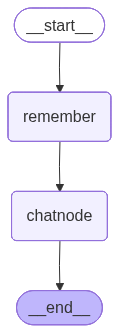

In [128]:
graph = StateGraph(MessagesState)

graph.add_node("remember", remember_node)
graph.add_node("chatnode", chat_node)


graph.add_edge(START, "remember")
graph.add_edge("remember", "chatnode")
graph.add_edge("chatnode", END)

workflow = graph.compile(store=store)
workflow

In [129]:
config = {"configurable": {"user_id":"rathan"}}

workflow.invoke({"messages": [{"role": "user", "content": "My name is rathan"}]}, config=config)

----------------------------
User Message:  My name is rathan
user meory data : 
LLM decision:  True
LLM memory content:  ['My name is rathan']
----------------------------
----------------------------
user memory:  My name is rathan
----------------------------


{'messages': [HumanMessage(content='My name is rathan', additional_kwargs={}, response_metadata={}, id='2563c036-411a-4251-ae27-6a0927741aba'),
  AIMessage(content='Noted.', additional_kwargs={}, response_metadata={}, id='cd55b34f-617c-46ff-a942-ba2956694ebe', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content=" Since you've just introduced yourself, I'll keep things simple for now. However, I am ready to learn more about you as our conversation progresses.\n\nHello Rathan, it's great to meet you. I'll keep track of our conversation and adjust my responses accordingly as we go along. What would you like to talk about or ask assistance with today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 72, 'prompt_tokens': 285, 'total_tokens': 357, 'completion_time': 0.165336451, 'completion_tokens_details': None, 'prompt_time': 0.01756263, 'prompt_tokens_details': None, 'queue_time': 0.05274479, 'total_time': 0.182899081}, 'model_name': 'llama-3.1-8b-ins

In [130]:
workflow.invoke({"messages": [{"role": "user", "content": "I am learning AI, tell about AI Agents"}]}, config=config)

----------------------------
User Message:  I am learning AI, tell about AI Agents
user meory data : My name is rathan
LLM decision:  True
LLM memory content:  ['I am rathan', 'I am learning AI']
----------------------------
----------------------------
user memory:  My name is rathan
I am rathan
I am learning AI
----------------------------


{'messages': [HumanMessage(content='I am learning AI, tell about AI Agents', additional_kwargs={}, response_metadata={}, id='04307390-55db-45ba-9d62-859e25324041'),
  AIMessage(content='Noted.', additional_kwargs={}, response_metadata={}, id='f4ca4630-f8f6-424c-a386-63e033881c7c', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content=" You're learning AI, and I'd be happy to help you with that. \n\nAI Agents, in the context of Artificial Intelligence, refer to software programs that can perform tasks autonomously, interact with their environment, and make decisions based on their perception of the world. These agents can be broadly classified into different types, based on their capabilities and behaviors.\n\nSome common types of AI Agents include:\n\n1. **Simple Reflex Agents**: These agents make decisions based on their current state and the current state of the environment. They react to stimuli without considering the consequences of their actions.\n2. **Model-Based Reflex Age

In [131]:
workflow.invoke({"messages": [{"role": "user", "content": "My name is rathan"}]}, config=config)

----------------------------
User Message:  My name is rathan
user meory data : My name is rathan/nI am rathan/nI am learning AI
LLM decision:  True
LLM memory content:  ['My name is rathan']
----------------------------
----------------------------
user memory:  My name is rathan
I am rathan
I am learning AI
My name is rathan
----------------------------


{'messages': [HumanMessage(content='My name is rathan', additional_kwargs={}, response_metadata={}, id='77a5d9ce-96eb-4f57-9577-0c71658135e1'),
  AIMessage(content='Noted.', additional_kwargs={}, response_metadata={}, id='eedb9d40-3d79-4f53-9ce9-38e60156bdfd', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content=" You've already mentioned your name, rathan. \n\nTo recap, here's what I know about you so far:\n\n1. Your name is rathan\n2. You're learning AI\n\nLet's start fresh then. How can I assist you in your AI learning journey, rathan?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 301, 'total_tokens': 361, 'completion_time': 0.281820757, 'completion_tokens_details': None, 'prompt_time': 0.207608282, 'prompt_tokens_details': None, 'queue_time': 0.055790012, 'total_time': 0.489429039}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs'

In [132]:
workflow.invoke({"messages": [{"role": "user", "content": "I am software engineer, tell about system desing"}]}, config=config)

----------------------------
User Message:  I am software engineer, tell about system desing
user meory data : My name is rathan/nI am rathan/nI am learning AI/nMy name is rathan
LLM decision:  False
LLM memory content:  ['I am rathan', 'I am software engineer']
----------------------------
----------------------------
user memory:  My name is rathan
I am rathan
I am learning AI
My name is rathan
----------------------------


{'messages': [HumanMessage(content='I am software engineer, tell about system desing', additional_kwargs={}, response_metadata={}, id='80764d9d-9993-407c-81d1-ccbe4f000832'),
  AIMessage(content='Noted.', additional_kwargs={}, response_metadata={}, id='47dc3f73-8263-4d88-841c-ced33fd8d2d5', tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content=" You're a software engineer, and you're learning about system design.\n\nSystem design is a crucial aspect of software development, focusing on creating a high-level structure for software systems. It involves considering the system's architecture, scalability, performance, and maintainability.\n\nAs a software engineer, you must have worked on various projects, and system design plays a vital role in ensuring these projects are successful. \n\nTo approach system design, you should consider the following key aspects:\n\n1. **Problem definition**: Clearly define the problem you're trying to solve and the requirements of the system.\n2. **Sys